# Computational Project: From Forces to Motion

## A no-coding investigation of projectile motion with drag

**Classical Mechanics — Taylor, Chapters 1–3**

In this project, you will do the physics and let the computer do the repetitive numerical work. You will:

1. draw a force diagram and write Newton's second law in Cartesian components;
2. enter your force equations and initial conditions into one input cell;
3. generate a numerical trajectory and several diagnostic plots;
4. use the plots to explain how force, momentum, and angular momentum change during the motion.

You are **not expected to know Python**. Only edit the green **STUDENT INPUT** cell. Run all other cells without changing them.

### Physical system

A ball is launched from ground level with initial speed $v_0$ at angle $\theta$. Gravity acts downward. The air exerts a linear drag force $\mathbf F_{\rm drag}=-b\mathbf v$.

Use $+x$ horizontally to the right and $+y$ vertically upward. Your model should have the form

$$m\ddot{x}=F_x, \qquad m\ddot{y}=F_y.$$

The origin is the launch point, so $x(0)=y(0)=0$.

## Part A — Do the physics first

Before running the simulation, write the following in your submitted work:

1. Determine what all your initial conditions are, choose values that you think are reasonable. (m, g, b, $v_0$, $\theta$, $y_0$, $t_{max}$)
2. Draw a free-body diagram after the ball has left the launcher and.
3. Draw a predicted trajectory with all the initial conditions.
4. Write the velocity vector in Cartesian components: $\mathbf v=v_x\hat{\mathbf x}+v_y\hat{\mathbf y}$.
5. Write the $x$- and $y$-components of the net force. Your expressions may use only the symbols listed below.
6. Predict how linear drag will change the maximum height, flight time, and range compared with motion in vacuum.
7. Predict whether the ball's angular momentum about the launch point will be conserved. Explain using torque.

### Symbols accepted by the notebook

| Symbol | Meaning | Units |
|---|---|---|
| `m` | mass | kg |
| `g` | gravitational-field magnitude | m/s² |
| `b` | linear-drag coefficient | kg/s |
| `t` | time | s |
| `x`, `y` | position components | m |
| `vx`, `vy` | velocity components | m/s |

Use `*` for multiplication. For example, $-b v_x$ is entered as `-b*vx`.


In [ ]:
#@title STUDENT INPUT — Edit only this cell { display-mode: "form" }
# Enter the force components you derived. Use * for multiplication.
Fx = "" #@param {type:"string"}
Fy = "" #@param {type:"string"}

# Physical parameters (SI units)
m = None #@param {type:"number"}
g = None #@param {type:"number"}
b = None #@param {type:"number"}

# Initial conditions
initial_speed = None #@param {type:"number"}
launch_angle_degrees = None #@param {type:"number"}
initial_height = None #@param {type:"number"}

# Simulation time (choose a value long enough for the ball to land)
maximum_time = None #@param {type:"number"}

print("Inputs saved. Now run the next cell.")

Inputs saved. Now run the next cell.


## Part B — Run the simulation

The next cell checks your force equations, solves Newton's second law numerically, and stops when the projectile reaches the ground. **Do not edit it.**

In [ ]:
#@title SIMULATION ENGINE — Run, but do not edit { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ast

if m <= 0:
    raise ValueError("Mass m must be positive.")
if g < 0 or b < 0 or maximum_time <= 0:
    raise ValueError("Use g >= 0, b >= 0, and maximum_time > 0.")

# Convert the student's force text into a restricted numerical function.
allowed_names = {"t", "x", "y", "vx", "vy", "m", "g", "b"}
def make_force(expression, component_name):
    try:
        tree = ast.parse(expression, mode="eval")
    except Exception as exc:
        raise ValueError(f"Could not read {component_name} = {expression!r}. Check * signs and parentheses.") from exc
    unknown = {node.id for node in ast.walk(tree) if isinstance(node, ast.Name)} - allowed_names
    if unknown:
        raise ValueError(f"Unknown symbol(s) in {component_name}: {unknown}. Use only the symbols in the table.")
    permitted = (ast.Expression, ast.BinOp, ast.UnaryOp, ast.Name, ast.Load,
                 ast.Constant, ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow,
                 ast.USub, ast.UAdd)
    if any(not isinstance(node, permitted) for node in ast.walk(tree)):
        raise ValueError(f"{component_name} contains an unsupported operation.")
    compiled = compile(tree, f"<{component_name}>", "eval")
    def evaluate(t, x, y, vx, vy, m, g, b):
        values = {"t": t, "x": x, "y": y, "vx": vx, "vy": vy, "m": m, "g": g, "b": b}
        return eval(compiled, {"__builtins__": {}}, values)
    return evaluate

force_x = make_force(Fx, "Fx")
force_y = make_force(Fy, "Fy")

theta = np.deg2rad(launch_angle_degrees)
state0 = [0.0, initial_height,
          initial_speed*np.cos(theta), initial_speed*np.sin(theta)]

def derivatives(t, state):
    x, y, vx, vy = state
    fx = float(force_x(t, x, y, vx, vy, m, g, b))
    fy = float(force_y(t, x, y, vx, vy, m, g, b))
    return [vx, vy, fx/m, fy/m]

def reaches_ground(t, state):
    # Ignore the launch instant so a ground-level launch does not stop immediately.
    return state[1] if t > 1e-8 else 1.0

reaches_ground.terminal = True
reaches_ground.direction = -1

solution = solve_ivp(derivatives, (0, maximum_time), state0,
                     events=reaches_ground, dense_output=True,
                     rtol=1e-9, atol=1e-11, max_step=0.03)

if len(solution.t_events[0]) > 0:
    flight_time = float(solution.t_events[0][0])
    landing_note = "Ground reached"
else:
    flight_time = maximum_time
    landing_note = "Ground not reached — increase maximum_time"

time = np.linspace(0, flight_time, 500)
x, y, vx, vy = solution.sol(time)
fx = np.array([force_x(T, X, Y, VX, VY, m, g, b) for T, X, Y, VX, VY in zip(time, x, y, vx, vy)], dtype=float)
fy = np.array([force_y(T, X, Y, VX, VY, m, g, b) for T, X, Y, VX, VY in zip(time, x, y, vx, vy)], dtype=float)
if fx.ndim == 0: fx = np.full_like(time, fx)
if fy.ndim == 0: fy = np.full_like(time, fy)

speed = np.hypot(vx, vy)
px, py = m*vx, m*vy
momentum = m*speed
Lz = m*(x*vy - y*vx)               # angular momentum about launch point
tau_z = x*fy - y*fx                 # torque about launch point

print(f"Model: Fx = {Fx}; Fy = {Fy}")
print(f"{landing_note}")
print(f"Flight time:    {flight_time:.3f} s")
print(f"Horizontal range: {x[-1]:.3f} m")
print(f"Maximum height: {np.max(y):.3f} m")

Model: Fx = -b*vx; Fy = -m*g+b*vy
Ground reached
Flight time:    1.573 s
Horizontal range: 11.115 m
Maximum height: 3.552 m


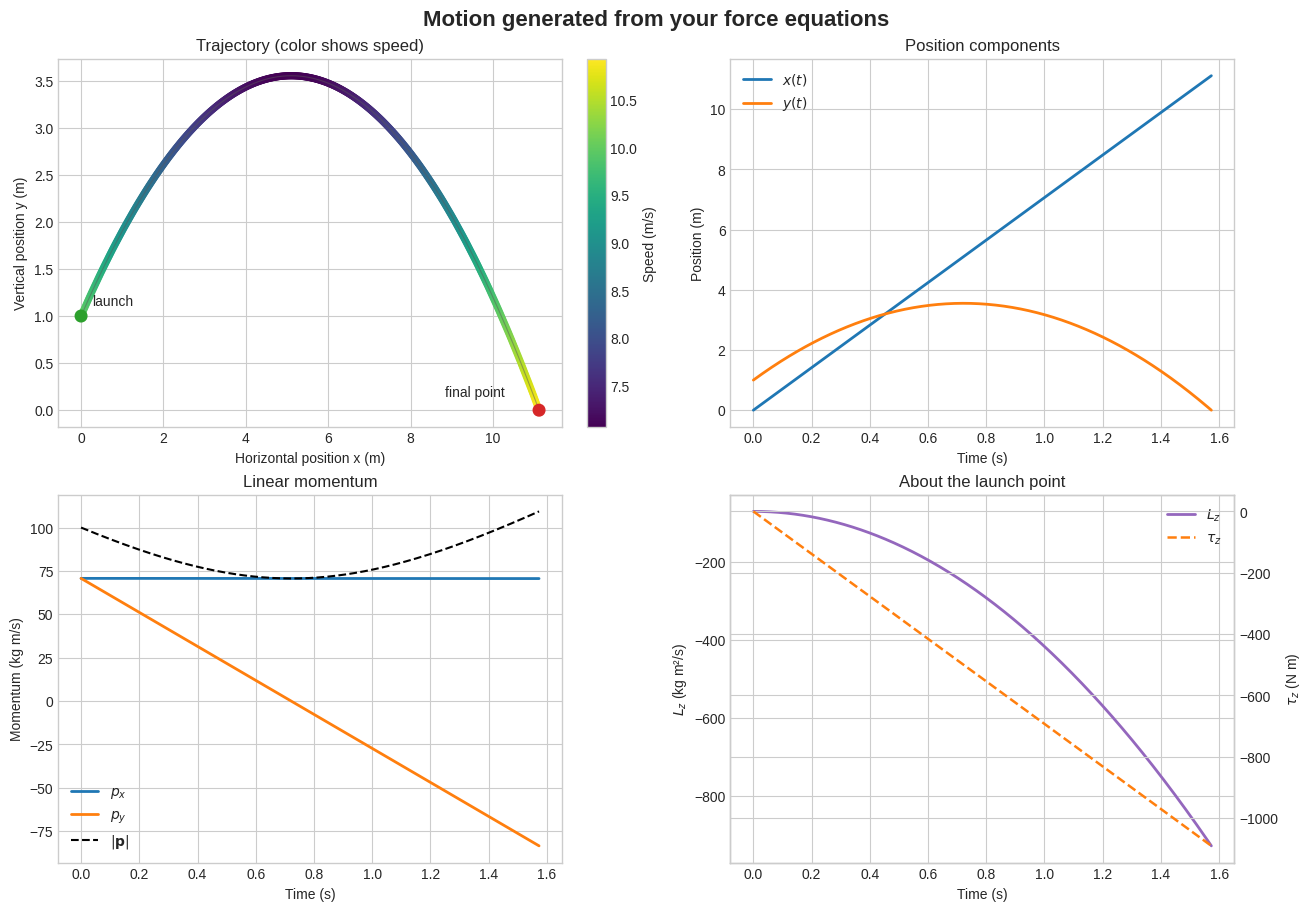

In [ ]:
#@title DESCRIPTIVE PLOTS — Run, but do not edit { display-mode: "form" }
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

# Trajectory colored by speed
sc = axes[0,0].scatter(x, y, c=speed, cmap="viridis", s=18)
axes[0,0].plot(x, y, color="0.35", lw=0.8, alpha=0.5)
axes[0,0].scatter([x[0], x[-1]], [y[0], y[-1]], c=["tab:green", "tab:red"], s=70, zorder=4)
axes[0,0].annotate("launch", (x[0], y[0]), xytext=(8, 8), textcoords="offset points")
axes[0,0].annotate("final point", (x[-1], y[-1]), xytext=(-68, 10), textcoords="offset points")
axes[0,0].set(xlabel="Horizontal position x (m)", ylabel="Vertical position y (m)", title="Trajectory (color shows speed)")
axes[0,0].set_ylim(bottom=min(-0.03*np.max(np.abs(y)+1), axes[0,0].get_ylim()[0]))
fig.colorbar(sc, ax=axes[0,0], label="Speed (m/s)")

# Positions
axes[0,1].plot(time, x, label="$x(t)$", lw=2)
axes[0,1].plot(time, y, label="$y(t)$", lw=2)
axes[0,1].set(xlabel="Time (s)", ylabel="Position (m)", title="Position components")
axes[0,1].legend()

# Momentum
axes[1,0].plot(time, px, label="$p_x$", lw=2)
axes[1,0].plot(time, py, label="$p_y$", lw=2)
axes[1,0].plot(time, momentum, label="$|\\mathbf{p}|$", color="black", ls="--")
axes[1,0].set(xlabel="Time (s)", ylabel="Momentum (kg m/s)", title="Linear momentum")
axes[1,0].legend()

# Angular momentum and torque (separate vertical scales)
axL = axes[1,1]
axT = axL.twinx()
line1 = axL.plot(time, Lz, color="tab:purple", lw=2, label="$L_z$")
line2 = axT.plot(time, tau_z, color="tab:orange", lw=1.8, ls="--", label="$\\tau_z$")
axL.set(xlabel="Time (s)", ylabel="$L_z$ (kg m²/s)", title="About the launch point")
axT.set_ylabel("$\\tau_z$ (N m)")
axL.legend(line1+line2, [q.get_label() for q in line1+line2], loc="best")

fig.suptitle("Motion generated from your force equations", fontsize=16, fontweight="bold")
plt.show()

## Part C — Interpret your model

Answer in complete sentences and refer to specific features or numerical values from your plots.

1. Report the flight time, maximum height, and horizontal range.
2. Explain why $p_x$ changes (or does not change) using your equation for $F_x$ and $F_x=dp_x/dt$.
3. Identify when the vertical momentum $p_y$ is zero. What is physically happening then?
4. Is angular momentum about the launch point conserved? Use the relationship $\boldsymbol\tau=d\mathbf L/dt$ and compare the $L_z$ and $\tau_z$ curves.
5. Does the trajectory agree with your predictions from Part A? Discuss any difference.

## Part D — Controlled comparison

Return to the **STUDENT INPUT** cell and set `b = 0`. Keep every other value unchanged, then rerun the notebook from that cell downward.

6. Record the new flight time, maximum height, and range. Calculate the percent change in range caused by drag.
7. Which momentum component behaves most differently when drag is removed? Explain directly from the force equations.
8. For the no-drag case, is angular momentum about the launch point conserved? Why or why not?

## Extension (Extra Credit)

Try one change that represents a physically different experiment—for example, double the mass while keeping $b$ fixed, change the launch angle, or use a more complex force model. State what you changed, make a prediction, and test it.

> **Submission:** Include your derivation/free-body diagram, answers to Parts A–D, and the plots from both the drag and no-drag trials. You will also submit the notebook via email. However the notebook code itself is not the focus; the quality of your physical model and interpretation is.
